# **UCI HAR - CNN Classification**
- accuracy : 94.04%(260412) → 95.05%(260414)
  - 수정 내용 표시 : ★

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [ ]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []  # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ') # 공백 2개를 1개로
                row_clean = row_clean.strip() # 양쪽 공백 제거
                serie = row_clean.split(' ') # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array) # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [ ]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# 모델 생성
- Layer : Conv층 4개 + dense층 2개

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

model = Sequential([
    Input(shape=input_shape),

    # 첫 번째 특징 추출
    Conv1D(128, 7, padding='same'),               #★ 필터수/KernelSize 확대
    BatchNormalization(),
    ReLU(),

    # 두 번째 특징 추출 (+ MaxPooling으로 압축)
    Conv1D(256, 5, padding='same'),               #★ 필터수/KernelSize 확대
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),
    Dropout(0.3),                                 #★ conv층 사이 Dropout 추가

    # 세 번째 특징 추출
    Conv1D(256, 5, padding='same'),               #★KernelSize 확대
    BatchNormalization(),
    ReLU(),

    # 네 번째 특징 추출 (+ MaxPooling으로 압축)   #★ Conv층 추가
    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),

    # 차원 축소 및 데이터 요약 : 1차원 벡터
    GlobalAveragePooling1D(),

    # 추출된 특징들을 조합하는 은닉층
    Dense(256, activation='relu'),                #★ 뉴런수 256으로 확장
    BatchNormalization(),                         #★ Dense층에도 BN 추가
    Dropout(0.5),                                 #★ 마지막 Dropout 조금 더 강하게

    # 최종적으로 6가지 행동 중 하나를 결정하는 출력 층
    Dense(num_classes, activation='softmax')
])

# 컴파일 설정
model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy', # 정답이 One-hot 형태가 아닌 정수 형태일 때 사용하는 손실 함수
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 128)       │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769,030 (2.93 MB)

 Trainable params: 766,726 (2.92 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


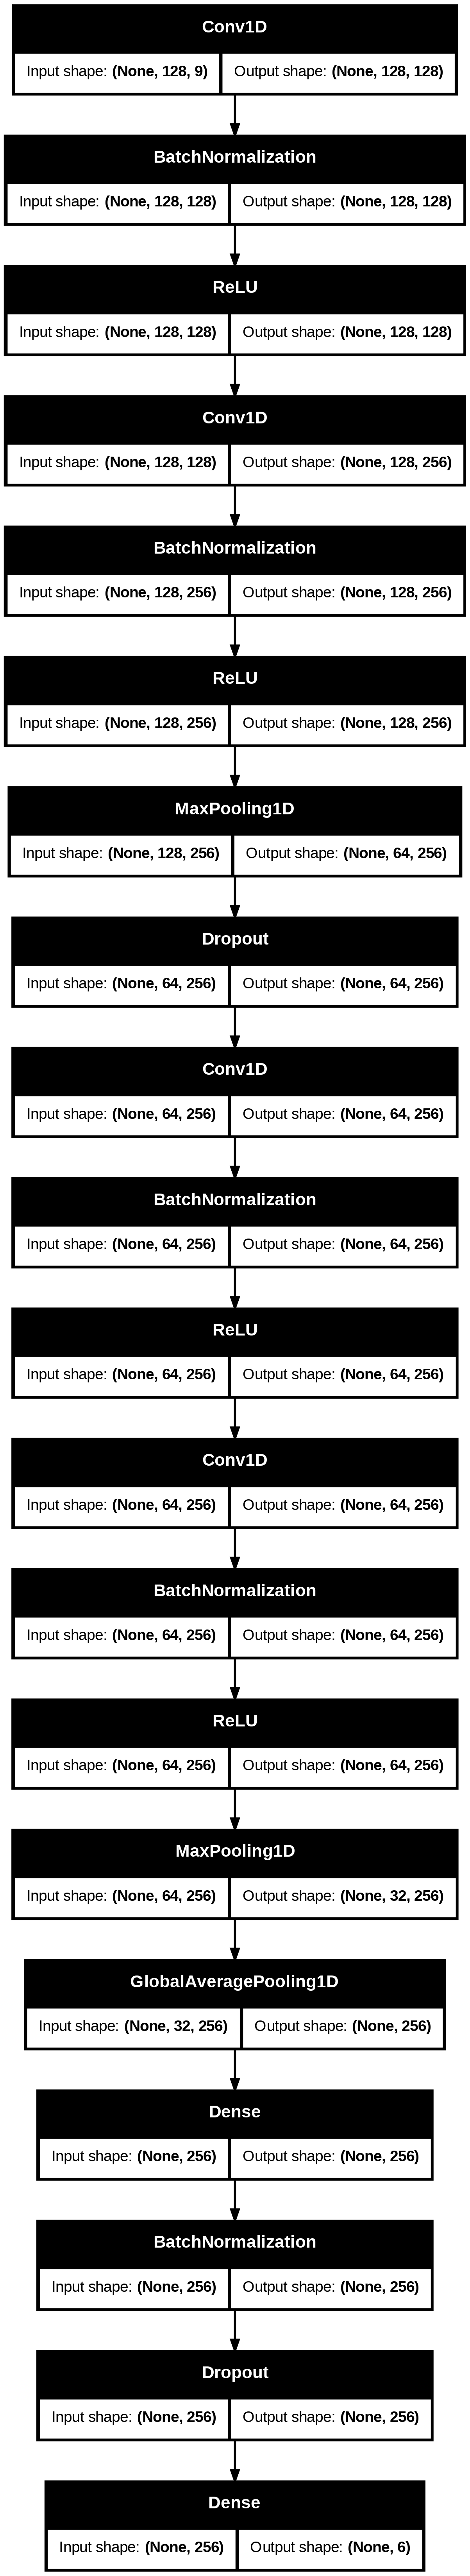

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks

In [ ]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_CNN_best.keras",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=35,           #★ 30 > 35 증가
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,            #★ 0.2 > 0.5 : lr 좀 더 천천히 감소하게끔
                patience=5,
                min_lr=0.00001,
                verbose=1
            )
        ]

# 모델 학습

In [ ]:
history = model.fit(
            X_train, y_train,
            epochs=150,               #★ 100>150 : 이전 학습시, 얼리스탑 없이 100epochs 끝까지 학습이 진행되어 epochs 확대
            batch_size=8,             #★ 64>8 : 한 번의 업데이트마다 모델이 보는 데이터의 범위 축소
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/150
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7607 - sparse_categorical_accuracy: 0.7363
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.90211, saving model to UCI_HAR_CNN_best.keras

Epoch 1: finished saving model to UCI_HAR_CNN_best.keras
736/736 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.5192 - sparse_categorical_accuracy: 0.8191 - val_loss: 0.2073 - val_sparse_categorical_accuracy: 0.9021 - learning_rate: 0.0010
Epoch 2/150
734/736 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2775 - sparse_categorical_accuracy: 0.9057
Epoch 2: val_sparse_categorical_accuracy improved from 0.90211 to 0.91638, saving model to UCI_HAR_CNN_best.keras

Epoch 2: finished saving model to UCI_HAR_CNN_best.keras
736/736 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2821 - sparse_categorical_accuracy: 0.8992 - val_loss: 0.3161 - val_sparse_categorical_accuracy: 0.9164 - learning_rate: 0.0010
Epoch 3/150
726/736 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2106 - sparse_categoric

# 모델 평가

In [ ]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_CNN_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 96.00%
Training loss: 0.1014
Test accuracy: 95.05%
Test loss: 0.1716


In [ ]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9980    0.9980       496
           1     1.0000    0.9873    0.9936       471
           2     0.9882    1.0000    0.9941       420
           3     0.8554    0.8554    0.8554       491
           4     0.8788    0.8722    0.8755       532
           5     0.9908    1.0000    0.9954       537

    accuracy                         0.9505      2947
   macro avg     0.9519    0.9521    0.9520      2947
weighted avg     0.9503    0.9505    0.9504      2947



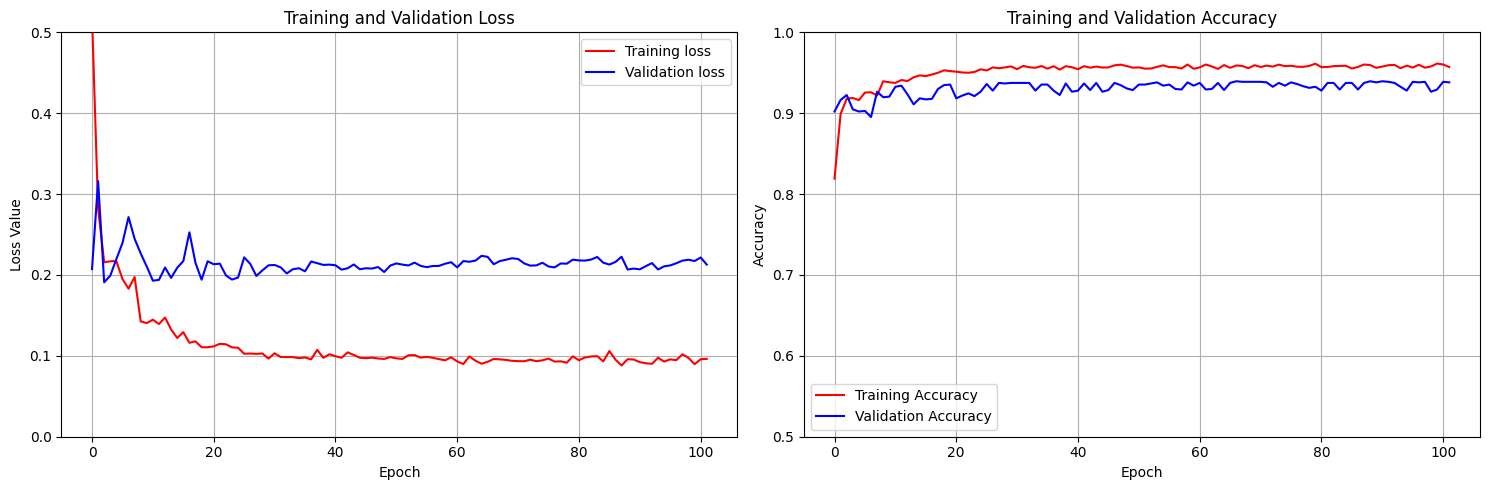

In [ ]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.ylim([0.0, 0.5])
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

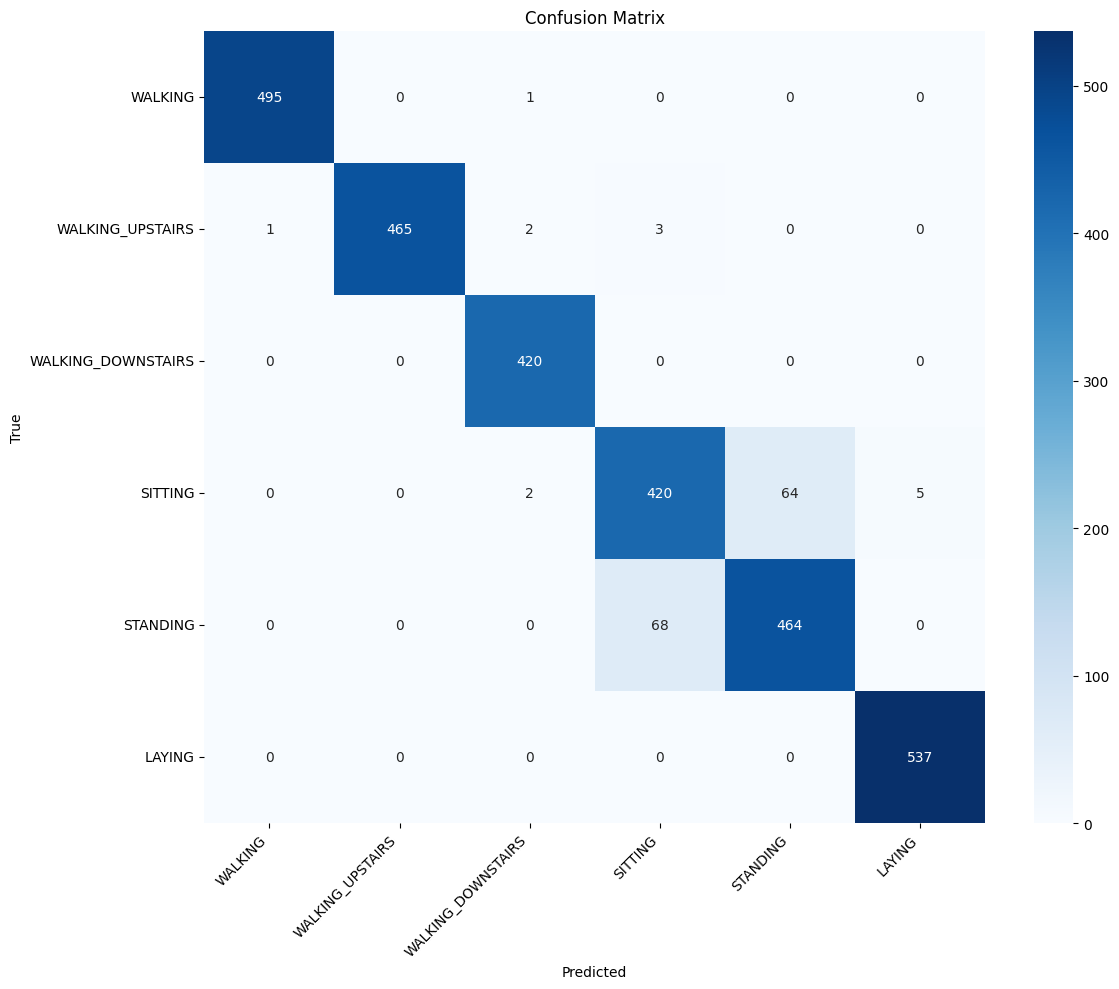

In [ ]:
# 히트맵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()